# Análise Google Play Store
Notebook de análise usando Pandas e Matplotlib.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Limpeza de dados
Remoção de duplicatas.

In [7]:
df = df.drop_duplicates()
df.shape

(10358, 13)

## Top 5 apps por número de instalações

In [8]:
top5_installs = (
    df.assign(Installs=df['Installs'].str.replace('[+,]', '', regex=True))
      .assign(Installs=lambda x: pd.to_numeric(x['Installs'], errors='coerce'))
      .sort_values('Installs', ascending=False)
      .head(5)
)

top5_installs[['App', 'Installs']]

,App,Installs
3454,Google Drive,1.000000e+09
865,Google Play Games,1.000000e+09
3523,Google Drive,1.000000e+09
2544,Facebook,1.000000e+09
2545,Instagram,1.000000e+09


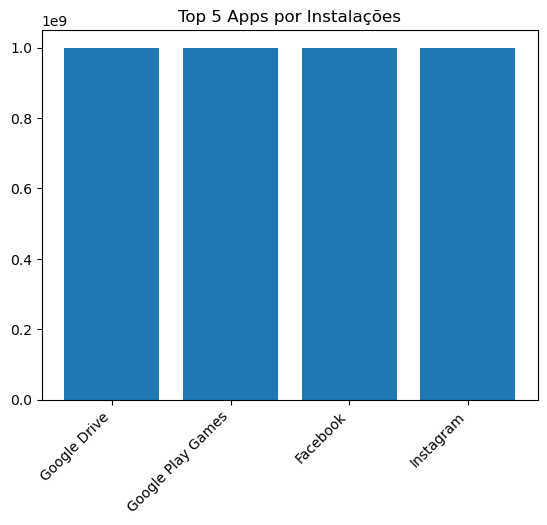

In [9]:
plt.figure()
plt.bar(top5_installs['App'], top5_installs['Installs'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 5 Apps por Instalações")
plt.show()

## Distribuição das 10 principais categorias (Pie Chart)

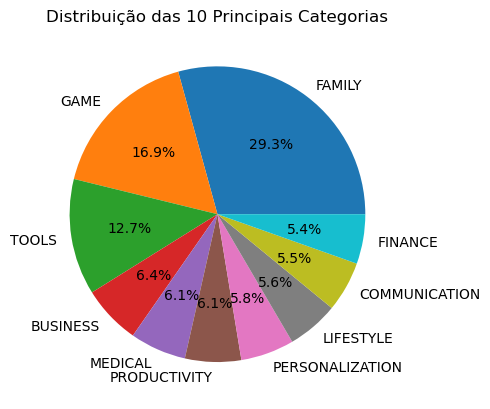

In [12]:
category_counts = df['Category'].value_counts()

top_categories = category_counts.head(10)

plt.figure()
plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%')
plt.title("Distribuição das 10 Principais Categorias")
plt.show()

## App mais caro

In [98]:
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df.sort_values('Price', ascending=False).iloc[0]


App               I'm Rich - Trump Edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                                275
Size                                  7.3M
Installs                           10,000+
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
Last Updated                   May 3, 2018
Current Ver                          1.0.1
Android Ver                     4.1 and up
Name: 4367, dtype: object

## Quantidade de apps Mature 17+

In [105]:
quantidade = df
quantidade[df['Content Rating'] == 'Mature 17+'].shape[0]

447

## Top 10 apps por número de reviews

In [100]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

top10_reviews = (df.sort_values('Reviews', ascending=False).head(10))

top10_reviews[['App', 'Reviews']]

,App,Reviews
2544,Facebook,78158306.0
3943,Facebook,78128208.0
336,WhatsApp Messenger,69119316.0
3904,WhatsApp Messenger,69109672.0
2604,Instagram,66577446.0
2545,Instagram,66577313.0
3909,Instagram,66509917.0
382,Messenger – Text and Video Chat for Free,56646578.0
335,Messenger – Text and Video Chat for Free,56642847.0
1879,Clash of Clans,44893888.0


## Cálculos adicionais

In [15]:
# Lista: Top 10 apps gratuitos mais bem avaliados
top_free = df[df['Type'] == 'Free'].sort_values('Rating', ascending=False).head(10)
top_free[['App', 'Rating']]

,App,Rating
10820,Fr. Daoud Lamei,5.0
7534,CL Strength,5.0
6726,COMSATS BOOK STORE FOR BS(CS),5.0
8234,DB Pickles,5.0
8230,DB HOME,5.0
7131,C B Patel Health Club,5.0
7127,CB VIDEO VISION,5.0
5196,AI Today : Artificial Intelligence News & AI 101,5.0
9511,Ek Bander Ne Kholi Dukan,5.0
9503,Pyaar Ek Dhoka,5.0


In [106]:
# Valor: Média de rating geral
media_rating = df['Rating'].mean()

print(f"Média geral de avaliação dos apps: {media_rating:.2f}")

Média geral de avaliação dos apps: 4.19


## Gráficos adicionais

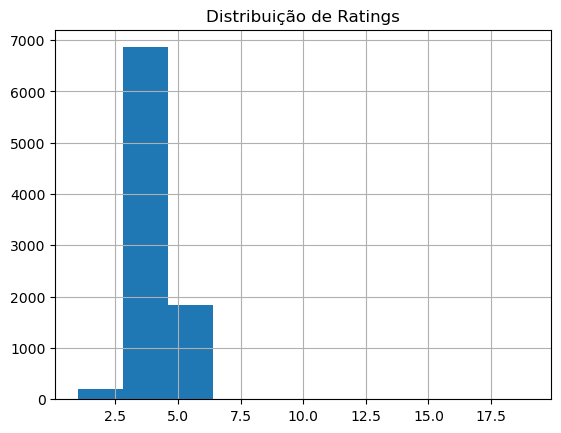

In [103]:
plt.figure()
df['Rating'].dropna().hist()
plt.title("Distribuição de Ratings")
plt.show()

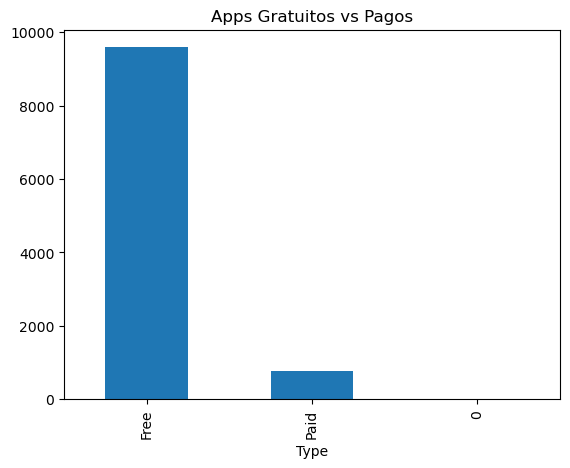

In [104]:
plt.figure()
df['Type'].value_counts().plot(kind='bar')
plt.title("Apps Gratuitos vs Pagos")
plt.show()